Import the chosen model

In [26]:
import sys
import os
import pandas as pd

# Add the absolute path to the scripts folder
scripts_path = os.path.abspath("../scripts")
sys.path.append(scripts_path)

from utils import load_model
from evaluation import error_analysis_loop

ImportError: cannot import name 'error_analysis_loop' from 'evaluation' (c:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\scripts\evaluation.py)

In [15]:
test_unprocessed = pd.read_csv("../data/interim/test_unprocessed.csv")
test_final = pd.read_csv("../data/processed/test_processed.csv")

In [16]:
X_test= test_final.drop(columns=["y"])
y_test = test_final["y"]   

In [17]:
models_dir = os.path.abspath("../models")



logreg_model = load_model("LogisticRegression", models_dir)

✅ Loaded LogisticRegression from c:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\models\LogisticRegression.pkl


### Error Analysis

In [18]:
y_pred =logreg_model.predict(X_test)
y_proba = logreg_model.predict_proba(X_test)[:, 1]


In [19]:
# Building dataset
error_df = test_unprocessed.copy()
error_df["target"] = y_test
error_df["predicted"] = y_pred
error_df["predicted_proba"] = y_proba
error_df["match"] = (y_test == y_pred).astype(int)
error_df["diff"] = y_test - y_proba



In [20]:
error_df

,job,marital,education,housing,loan,contact,month,day_of_week,age,pdays,emp_var_rate,cons_conf_idx,age_group,housing_loan_interaction,target,predicted,predicted_proba,match,diff
0,blue-collar,married,high.school,no,no,cellular,may,tue,33,999,-1.8,-46.2,adult,no_no,0,1,0.540798,0,-0.540798
1,admin.,married,university.degree,no,no,cellular,may,tue,39,999,-1.8,-46.2,adult,no_no,0,1,0.551772,0,-0.551772
2,services,single,university.degree,yes,no,cellular,may,tue,32,999,-1.8,-46.2,adult,yes_no,0,1,0.548660,0,-0.548660
3,admin.,divorced,high.school,no,no,cellular,may,tue,47,999,-1.8,-46.2,adult,no_no,0,0,0.417534,1,-0.417534
4,technician,married,university.degree,unknown,unknown,cellular,may,tue,43,999,-1.8,-46.2,adult,unknown_unknown,1,0,0.394759,0,0.605241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7738,retired,married,professional.course,yes,no,cellular,nov,fri,73,999,-1.1,-50.8,senior,yes_no,1,0,0.399651,0,0.600349
7739,blue-collar,married,professional.course,no,no,cellular,nov,fri,46,999,-1.1,-50.8,adult,no_no,0,0,0.321477,1,-0.321477
7740,retired,married,university.degree,yes,no,cellular,nov,fri,56,999,-1.1,-50.8,senior,yes_no,0,1,0.524678,0,-0.524678
7741,technician,married,professional.course,no,no,cellular,nov,fri,44,999,-1.1,-50.8,adult,no_no,1,0,0.307206,0,0.692794


In [21]:
numerical_columns = error_df.select_dtypes(include=['number'])
categorical_columns = error_df.select_dtypes(include=['object', 'category'])


Match rate by age_group:
age_group    match
    adult 0.456900
  elderly 0.531532
   senior 0.471580
    youth 0.418288

Match rate by housing:
housing    match
     no 0.449969
unknown 0.592965
    yes 0.460520

Match rate by loan:
   loan    match
     no 0.452078
unknown 0.592965
    yes 0.477331

Match rate by day_of_week:
day_of_week    match
        fri 0.498686
        mon 0.458770
        thu 0.432996
        tue 0.494441
        wed 0.415297

Match rate by housing_loan_interaction:
housing_loan_interaction    match
                   no_no 0.435000
                  no_yes 0.545662
         unknown_unknown 0.592965
                  yes_no 0.465455
                 yes_yes 0.436389

Match rate by education:
          education    match
           basic.4y 0.580175
           basic.6y 0.371134
           basic.9y 0.428571
        high.school 0.478004
         illiterate 0.500000
professional.course 0.520790
  university.degree 0.404540
            unknown 0.518987

Match rate 

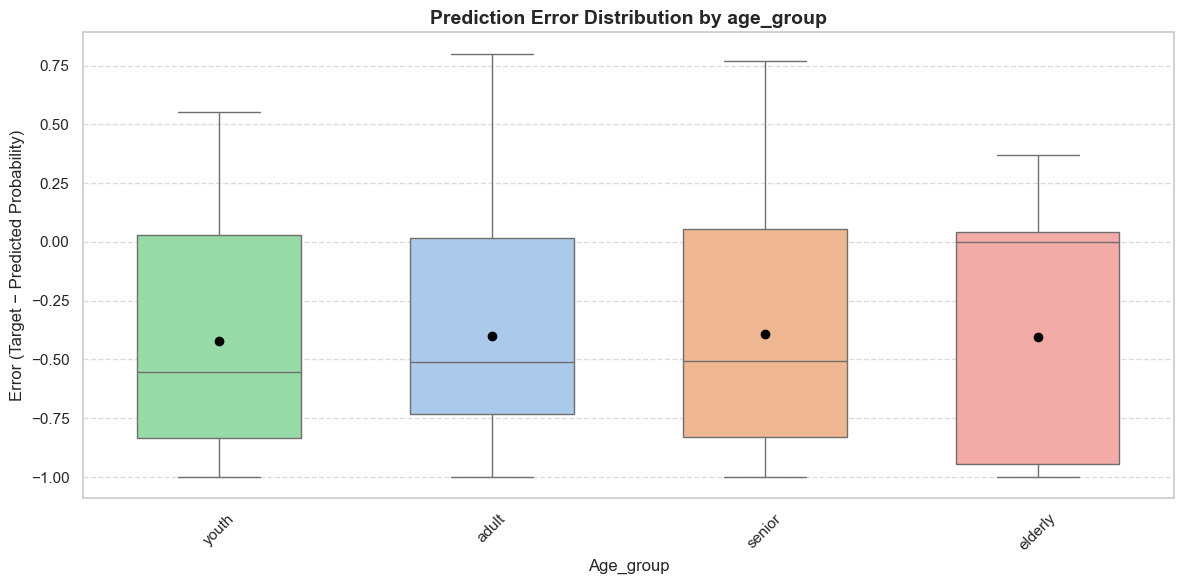

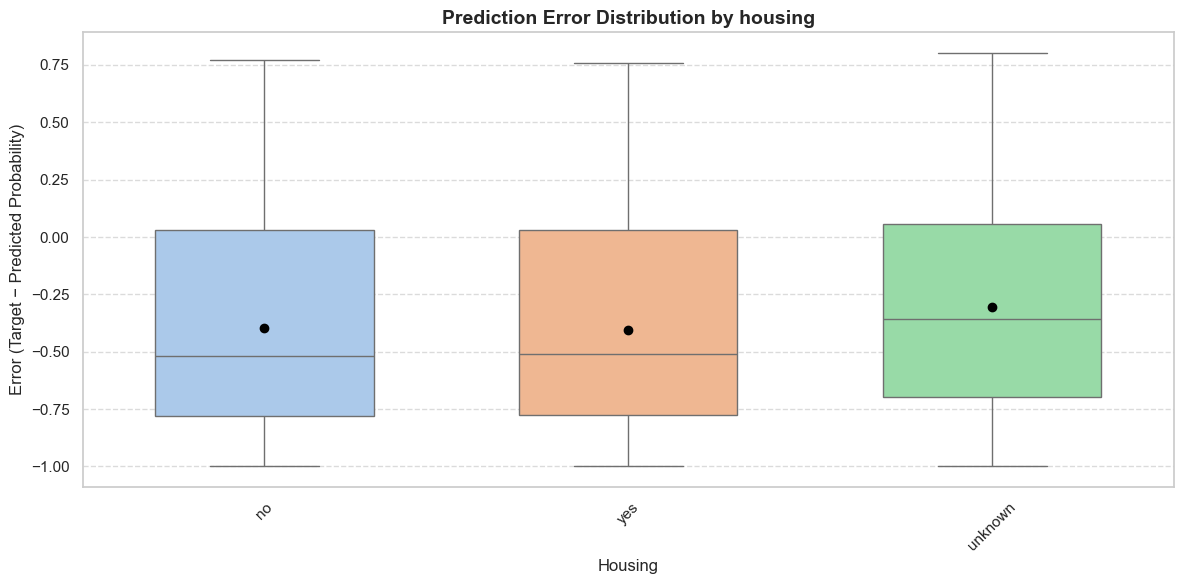

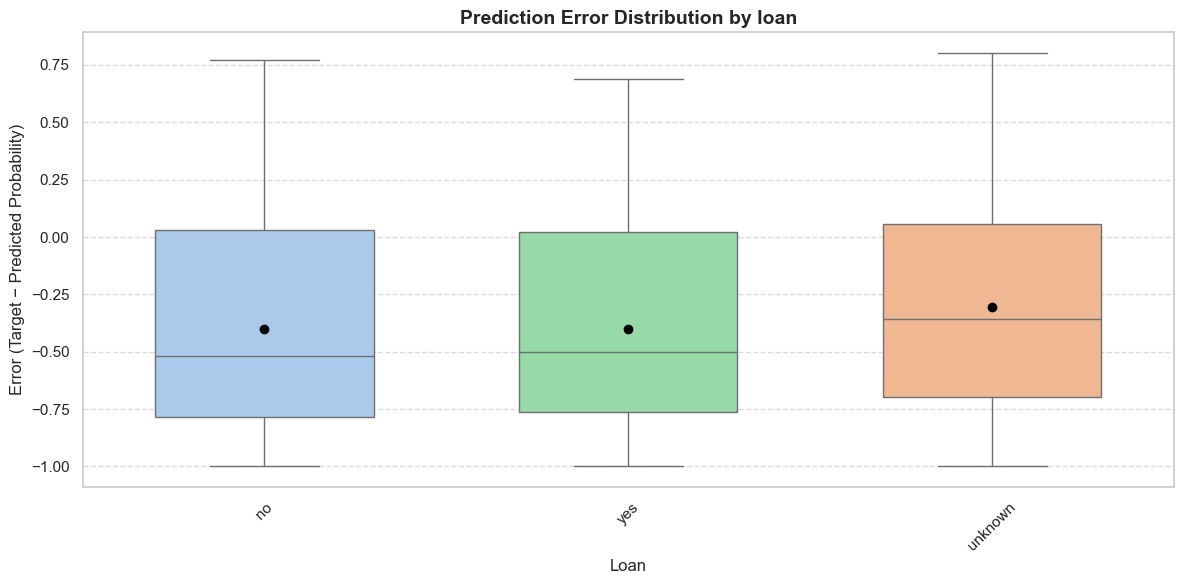

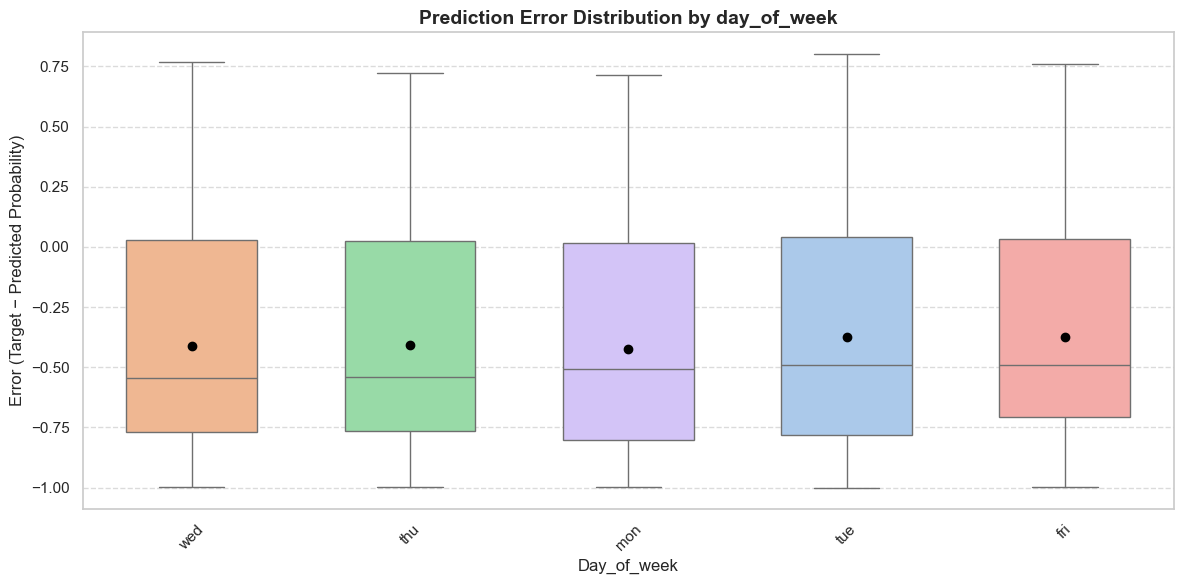

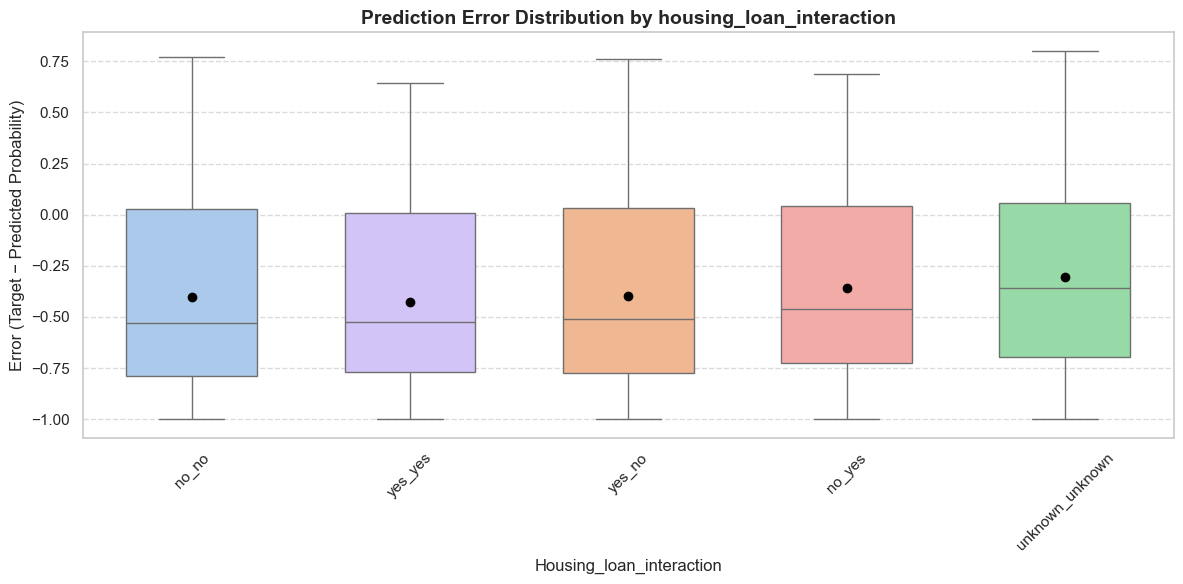

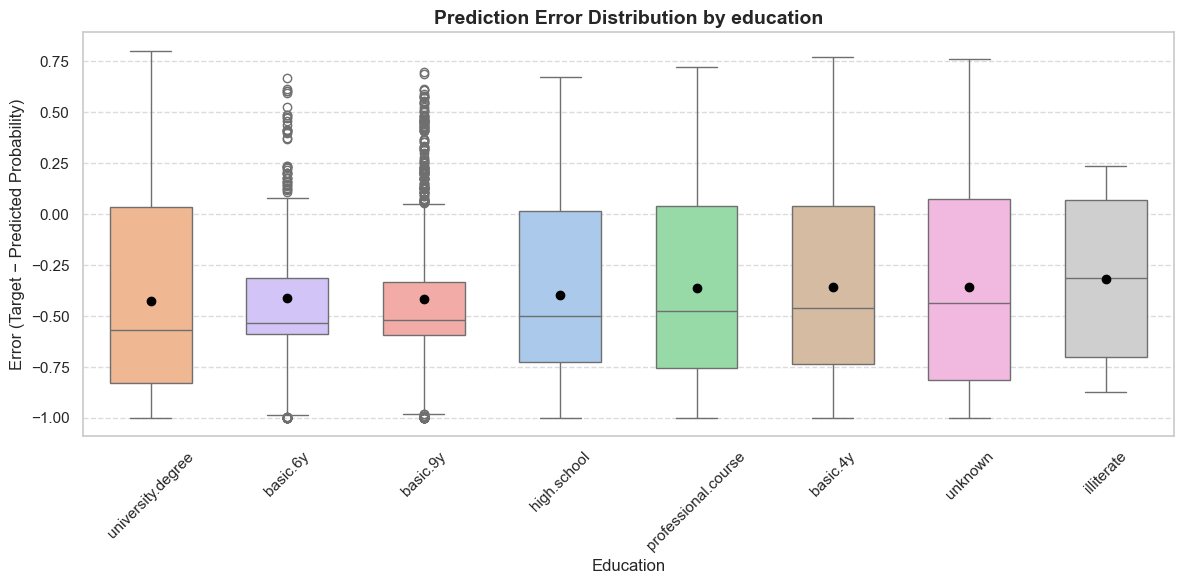

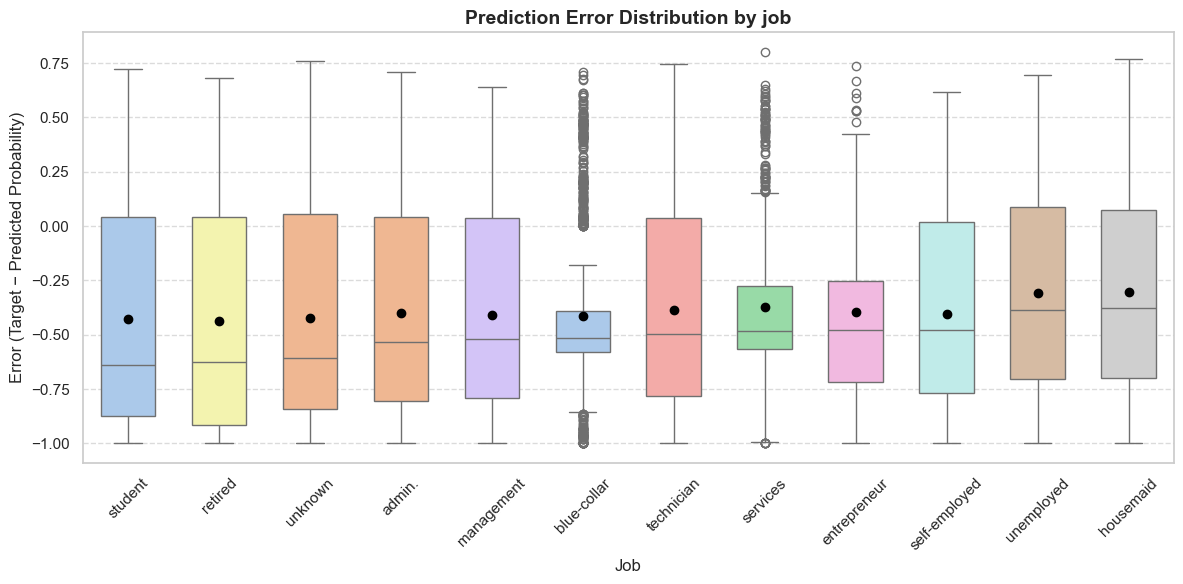

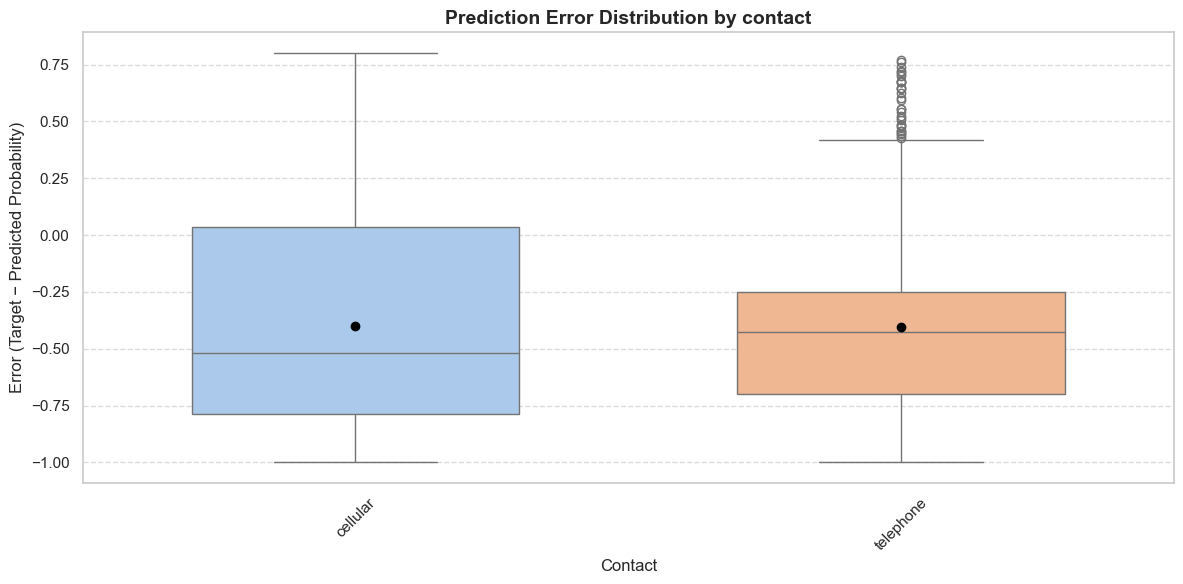

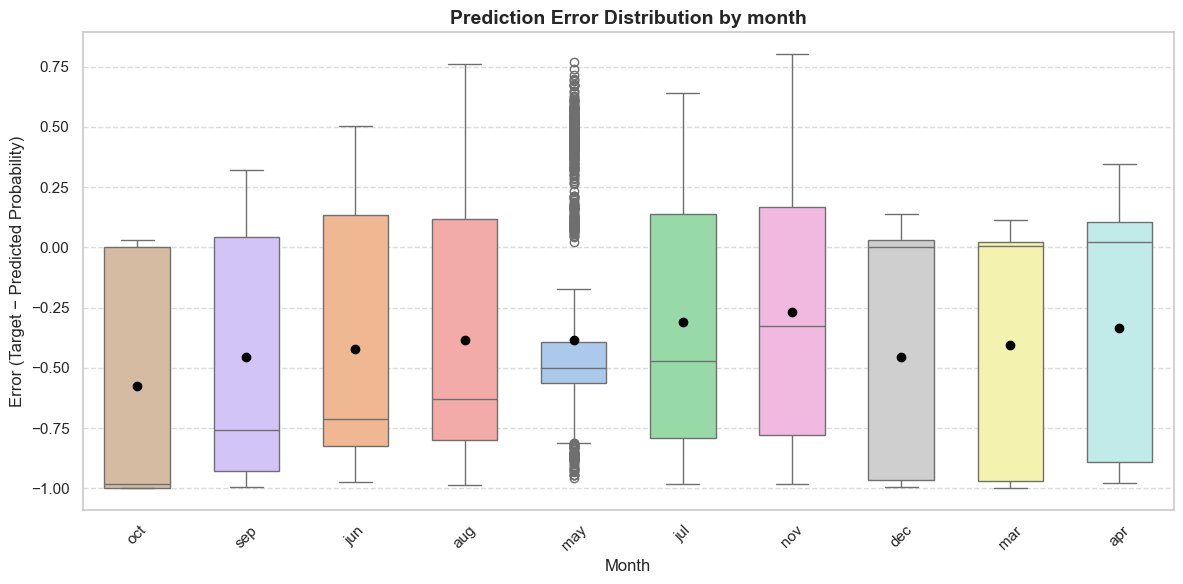

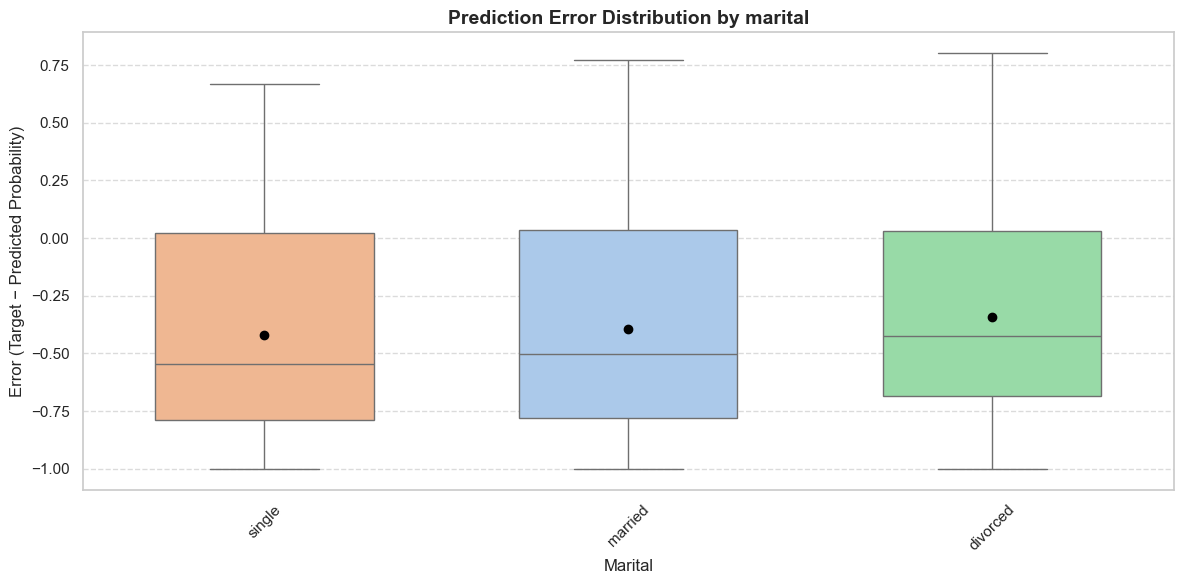

In [24]:
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure save directory exists
save_dir = "reports/figures"
os.makedirs(save_dir, exist_ok=True)

# Identify categorical predictors present in the dataset
categorical_predictors = list(set(categorical_columns).intersection(set(error_df.columns)))

for categorical_predictor in categorical_predictors:
    # --- Print summary table ---
    summary = (
        error_df
        .groupby(categorical_predictor)["match"]
        .mean()
        .reset_index()
    )
    print(f"\nMatch rate by {categorical_predictor}:")
    print(summary.to_string(index=False))

    # --- Order categories by median error for clarity ---
    order = (
        error_df.groupby(categorical_predictor)["diff"]
        .median()
        .sort_values()
        .index
    )

    # --- Polished boxplot ---
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=error_df,
        x=categorical_predictor,
        y="diff",
        hue=categorical_predictor,
        order=order,
        palette="pastel",
        width=0.6,
        showmeans=True,
        meanprops={"marker":"o","markerfacecolor":"black","markeredgecolor":"black"}
    )

    plt.title(f"Prediction Error Distribution by {categorical_predictor}", fontsize=14, weight="bold")
    plt.ylabel("Error (Target − Predicted Probability)")
    plt.xlabel(categorical_predictor.capitalize())
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()

    save_dir= os.path.abspath("../reports/figures")

    save_path = os.path.join(save_dir, f"{categorical_predictor}_error_analysis.png")
    plt.savefig(save_path, dpi=300)   # dpi=300 for high quality

In [23]:

numerical_predictors = list(set(numerical_columns).intersection(set(error_df.columns)))


In [ ]:
for numerical_predictor in numerical_predictors:
    # --- Print summary table ---
    summary = (
        error_df
        .groupby(numerical_predictor)["match"]
        .mean()
        .reset_index()
    )
    print(f"\nMatch rate by {numerical_predictor}:")
    print(summary.to_string(index=False))
    
    
    

['target',
 'pdays',
 'age',
 'cons_conf_idx',
 'predicted',
 'predicted_proba',
 'match',
 'diff',
 'emp_var_rate']